In [33]:
import pandas                           as pd 
import numpy                            as np
import matplotlib.pyplot                as plt

from sklearn.preprocessing              import StandardScaler
from sklearn.cluster                    import KMeans
from sklearn.metrics                    import silhouette_score
from sklearn.decomposition              import PCA
from scipy.cluster.hierarchy            import dendrogram, linkage, fcluster
from sklearn.cluster                    import AgglomerativeClustering

In [10]:
df = pd.read_excel('Data/EV_Data.xlsx')

In [11]:
print(df.groupby(["EV Type", df["Electric Range"].eq(0).map({True: "range=0", False: "range>0"})]).size())

EV Type  Electric Range
BEV      range=0           177921
         range>0            45944
PHEV     range>0            55880
dtype: int64


In [12]:
df.columns

Index(['VIN', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make',
       'Model', 'EV Type', 'CAFV Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Electric Utility',
       'Census Tract', 'Longitude', 'Latitude'],
      dtype='object')

# **Feature Engineering**

In [ ]:
CURRENT_YEAR = 2024

# Vehicle Age
df['Vehicle Age'] = CURRENT_YEAR - df['Model Year']

# EV Type
df['EV Type'] = df['EV Type'].str.upper().str.contains('BEV').astype(int)

# make_median_enc
## Tính median chỉ trên range > 0
valid = df[df['Electric Range'] > 0]
make_median = valid.groupby('Make')['Electric Range'].median()

# Map vào toàn bộ dataset, hãng chưa gặp → dùng global median
global_median = valid['Electric Range'].median()
df['make_median_enc'] = df['Make'].map(make_median).fillna(global_median)

# model_count
df['model_count'] = df.groupby(['Make', 'Model'])['Make'].transform('count')

#print(df.head(3))

          VIN  County     City State  Postal Code  Model Year  Make   Model  \
0  1FTZR0813X  Pierce   Graham    WA        98338        1999  FORD  RANGER   
1  1FTZR0812X  Pierce   Graham    WA        98338        1999  FORD  RANGER   
2  1FTZR0819Y    King  Seattle    WA        98116        2000  FORD  RANGER   

   EV Type CAFV Eligibility  Electric Range  Legislative District  \
0        1         Eligible              74                   2.0   
1        1         Eligible              74                   2.0   
2        1         Eligible              58                  34.0   

   DOL Vehicle ID                                   Electric Utility  \
0       169463255  BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...   
1       215121742  BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...   
2       279142559       CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)   

   Census Tract  Longitude  Latitude  Vehicle Age  make_median_enc  \
0   53053073116 -122.29477  47.05703           

In [14]:
print(df.columns)

Index(['VIN', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make',
       'Model', 'EV Type', 'CAFV Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Electric Utility',
       'Census Tract', 'Longitude', 'Latitude', 'Vehicle Age',
       'make_median_enc', 'model_count'],
      dtype='object')


# **Chuẩn hóa dữ liệu**

In [18]:
features = ['Vehicle Age', 'EV Type', 'make_median_enc', 'model_count']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# **Clustering**

**1. K Means**

In [20]:
# Tìm k tối ưu - Elbow Method + Silhouette Score

X_sample = X_scaled.sample(n=30000, random_state=42)

inertia    = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=10000))

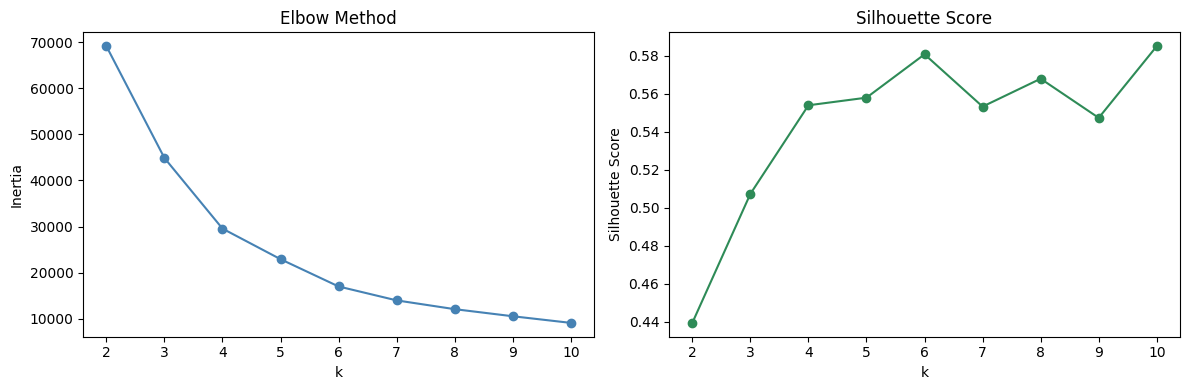

Silhouette scores:
  k=2: 0.4393
  k=3: 0.5072
  k=4: 0.5538
  k=5: 0.5579
  k=6: 0.5807
  k=7: 0.5532
  k=8: 0.5678
  k=9: 0.5472
  k=10: 0.5850


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertia, marker='o', color='steelblue')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))

ax2.plot(k_range, sil_scores, marker='o', color='seagreen')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

print('Silhouette scores:')
for k, s in zip(k_range, sil_scores):
    print(f'  k={k}: {s:.4f}')

In [22]:
# Gọm cụm với số cụm = 4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print('Phân bố cluster:')
print(df['cluster'].value_counts().sort_index())
print()
print('% fleet mỗi cluster:')
print((df['cluster'].value_counts().sort_index() / len(df) * 100).round(1).astype(str) + '%')

Phân bố cluster:
cluster
0    88310
1    93829
2    46054
3    51552
Name: count, dtype: int64

% fleet mỗi cluster:
cluster
0    31.6%
1    33.5%
2    16.5%
3    18.4%
Name: count, dtype: object


In [24]:
# Profile mỗi cụm 
profile = df.groupby('cluster')[['Vehicle Age', 'EV Type', 'make_median_enc', 'model_count']].mean().round(2)

profile.columns = ['vehicle_age (mean)', 'is_bev (mean)', 'make_median_enc (mean)', 'model_count (mean)']
print(profile)

for c in sorted(df['cluster'].unique()):
    top_makes = (df[df['cluster'] == c]['Make']
                 .value_counts()
                 .head(3))
    print(f'Cluster {c}: {top_makes.index.tolist()}')

         vehicle_age (mean)  is_bev (mean)  make_median_enc (mean)  \
cluster                                                              
0                      0.83           1.00                  220.00   
1                      0.45           1.00                   72.08   
2                      6.59           0.91                  187.22   
3                      2.34           0.00                   32.13   

         model_count (mean)  
cluster                      
0                  53015.05  
1                   3805.19  
2                  14243.35  
3                   2594.53  
Cluster 0: ['TESLA']
Cluster 1: ['FORD', 'KIA', 'HYUNDAI']
Cluster 2: ['TESLA', 'CHEVROLET', 'NISSAN']
Cluster 3: ['TOYOTA', 'JEEP', 'BMW']


In [29]:
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f'Variance explained: {pca.explained_variance_ratio_.sum():.1%}')

Variance explained: 77.5%


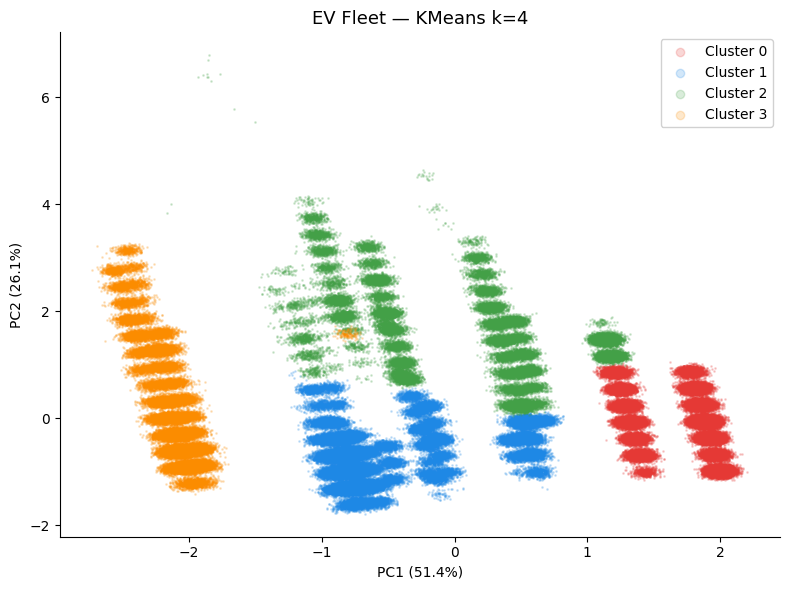

In [32]:
np.random.seed(42)
jitter = np.random.normal(0, 0.05, size=X_2d.shape)
X_2d_jitter = X_2d + jitter

colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00']

fig, ax = plt.subplots(figsize=(8, 6))

for c in range(4):
    mask = df['cluster'].values == c
    ax.scatter(X_2d_jitter[mask, 0], X_2d_jitter[mask, 1],
                s=1, alpha=0.2,
                color=colors[c],
                label=f'Cluster {c}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('EV Fleet — KMeans k=4', fontsize=13)
ax.legend(markerscale=6, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Cluster 0 — "BEV cao cấp mới"**
Xe thuần điện đời mới, gần như toàn Tesla, range cao (~220 miles), phổ biến nhất trong fleet.

**Cluster 1 — "BEV phổ thông tầm ngắn"**
Xe thuần điện mới nhưng range thấp (~72 miles). Chủ yếu Ford, Kia, Hyundai — đang thâm nhập thị trường.

**Cluster 2 — "BEV thế hệ cũ"**
Xe thuần điện đời cũ nhất (vehicle_age ≈ 6.6 năm). Tesla cũ, Chevrolet, Nissan Leaf — thế hệ EV tiên phong.

**Cluster 3 — "PHEV hybrid"**
Toàn xe hybrid plug-in, không có BEV. Toyota, Jeep, BMW. Range điện thấp (~32 miles), chạy xăng là chính.